# Trabajo de dataset con los climas de las cuidades agregados

importamos las librerias necesarias

In [1]:
import pandas as pd
import numpy as np
import Funciones as f
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.constants import convert_temperature
import plotly.express as px
from pint import UnitRegistry
from currency_converter import CurrencyConverter

# Haremos la limpieza de los datos y la unión de los datasets para poder hacer el análisis de datos

In [2]:
df=pd.read_csv("data/eventos_entregas.csv")

In [3]:
f.explorar_df(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170820 entries, 0 to 170819
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   event_id            170820 non-null  object
 1   load_id             170820 non-null  object
 2   trip_id             170820 non-null  object
 3   event_type          170820 non-null  object
 4   facility_id         170820 non-null  object
 5   scheduled_datetime  170820 non-null  object
 6   actual_datetime     170820 non-null  object
 7   detention_minutes   170820 non-null  int64 
 8   on_time_flag        170820 non-null  bool  
 9   location_city       170820 non-null  object
 10  location_state      170820 non-null  object
dtypes: bool(1), int64(1), object(9)
memory usage: 13.2+ MB
None
Primeras filas
      event_id       load_id       trip_id event_type facility_id  \
0  EVT00000001  LOAD00000001  TRIP00000001     Pickup    FAC00034   
1  EVT00000002  LOAD00000001  TRIP

In [4]:
df.columns

Index(['event_id', 'load_id', 'trip_id', 'event_type', 'facility_id',
       'scheduled_datetime', 'actual_datetime', 'detention_minutes',
       'on_time_flag', 'location_city', 'location_state'],
      dtype='object')

In [5]:
columna={'event_id':'id_evento', 'load_id':'id_carga', 'trip_id':'id_viaje', 'event_type':'tipo_evento', 'facility_id':'id_instalación',
'scheduled_datetime':'fecha_hora_programada', 'actual_datetime':'fecha_hora_real', 'detention_minutes':'minutos_de_detencion',
'on_time_flag':'indicador_tiempo_hora', 'location_city':'ciudad', 'location_state':'estado'}

In [6]:
df=df.rename(columns=columna)

In [7]:
df.head()

,id_evento,id_carga,id_viaje,tipo_evento,id_instalación,fecha_hora_programada,fecha_hora_real,minutos_de_detencion,indicador_tiempo_hora,ciudad,estado
0,EVT00000001,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01 18:00:00.000000,2022-01-01 20:58:55.918185,0,False,Houston,TX
1,EVT00000002,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02 23:10:55.918185,2022-01-02 21:30:22.142060,230,True,Detroit,MI
2,EVT00000003,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01 18:00:00.000000,2022-01-01 17:37:26.608430,62,True,Kansas City,MO
3,EVT00000004,LOAD00000002,TRIP00000002,Delivery,FAC00050,2022-01-02 02:13:26.608430,2022-01-02 05:55:46.238257,67,False,Indianapolis,IN
4,EVT00000005,LOAD00000003,TRIP00000003,Pickup,FAC00001,2022-01-01 08:00:00.000000,2022-01-01 07:28:02.169634,83,True,Columbus,OH


veamos el evento

In [8]:
f.categorico(df,"tipo_evento")

tipo_evento
Pickup      85410
Delivery    85410
Name: count, dtype: int64
['Pickup' 'Delivery']
2


In [9]:
f.categorico(df,"ciudad")

ciudad
Kansas City     14562
Philadelphia    12031
Portland        11773
Seattle         11768
Columbus        10593
Charlotte       10267
Houston         10263
Los Angeles      8948
Minneapolis      8737
Miami            8709
New York         7485
Denver           7368
Chicago          7350
Las Vegas        7344
Dallas           7279
Memphis          5908
Indianapolis     5810
Atlanta          5763
Phoenix          4456
Detroit          4406
Name: count, dtype: int64
['Houston' 'Detroit' 'Kansas City' 'Indianapolis' 'Columbus' 'Portland'
 'Phoenix' 'Denver' 'Seattle' 'Chicago' 'Las Vegas' 'Philadelphia' 'Miami'
 'Memphis' 'Minneapolis' 'Atlanta' 'Charlotte' 'New York' 'Los Angeles'
 'Dallas']
20


Acotaremos nuestro estudio a 7 ciudades

In [10]:
ciudades={"Houston", "Portland", "Detroit", "Kansas City", "Los Angeles", "Miami", "New York"}

In [11]:
df_estudio=f.filtrar_fila(df,"ciudad",ciudades)

In [12]:
df_estudio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66146 entries, 0 to 170819
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id_evento              66146 non-null  object
 1   id_carga               66146 non-null  object
 2   id_viaje               66146 non-null  object
 3   tipo_evento            66146 non-null  object
 4   id_instalación         66146 non-null  object
 5   fecha_hora_programada  66146 non-null  object
 6   fecha_hora_real        66146 non-null  object
 7   minutos_de_detencion   66146 non-null  int64 
 8   indicador_tiempo_hora  66146 non-null  bool  
 9   ciudad                 66146 non-null  object
 10  estado                 66146 non-null  object
dtypes: bool(1), int64(1), object(9)
memory usage: 5.6+ MB


In [13]:
df_estudio.head()

,id_evento,id_carga,id_viaje,tipo_evento,id_instalación,fecha_hora_programada,fecha_hora_real,minutos_de_detencion,indicador_tiempo_hora,ciudad,estado
0,EVT00000001,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01 18:00:00.000000,2022-01-01 20:58:55.918185,0,False,Houston,TX
1,EVT00000002,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02 23:10:55.918185,2022-01-02 21:30:22.142060,230,True,Detroit,MI
2,EVT00000003,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01 18:00:00.000000,2022-01-01 17:37:26.608430,62,True,Kansas City,MO
5,EVT00000006,LOAD00000003,TRIP00000003,Delivery,FAC00022,2022-01-03 04:28:02.169634,2022-01-03 03:05:02.833256,11,True,Portland,OR
8,EVT00000009,LOAD00000005,TRIP00000005,Pickup,FAC00046,2022-01-01 08:00:00.000000,2022-01-01 11:51:35.544202,73,False,Houston,TX


Veamos un mapa de distribución de las entregas y envíos en las 7 ciudades de estudio

In [14]:
# Agrupar por estado para contar eventos
df_ciudad = df_estudio['estado'].value_counts().reset_index()
df_ciudad.columns = ['estado', 'conteo']

In [15]:
fig = px.choropleth(df_ciudad, 
                    locations='estado', 
                    locationmode="USA-states", 
                    color='conteo',
                    scope="usa",
                    title='Distribución de Eventos de Carga por Estado',
                    color_continuous_scale="Viridis")
fig.show()

In [16]:
f.categorico(df_estudio,"tipo_evento")

tipo_evento
Delivery    36968
Pickup      29178
Name: count, dtype: int64
['Pickup' 'Delivery']
2


Creemos una columna solo con la fecha

In [17]:
df_estudio = f.separa_fecha_hora(df_estudio,"fecha_hora_real")

c:\Users\tachi\Documents\git\Proyecto_Clima_Log-stica_Empresarial\Notebook\Funciones.py:74: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\tachi\Documents\git\Proyecto_Clima_Log-stica_Empresarial\Notebook\Funciones.py:75: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\tachi\Documents\git\Proyecto_Clima_Log-stica_Empresarial\Notebook\Funciones.py:76: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

In [18]:
df_estudio.head()

,id_evento,id_carga,id_viaje,tipo_evento,id_instalación,fecha_hora_programada,fecha_hora_real,minutos_de_detencion,indicador_tiempo_hora,ciudad,estado,fecha,hora
0,EVT00000001,LOAD00000001,TRIP00000001,Pickup,FAC00034,2022-01-01 18:00:00.000000,2022-01-01 20:58:55,0,False,Houston,TX,2022-01-01,20:58:55
1,EVT00000002,LOAD00000001,TRIP00000001,Delivery,FAC00046,2022-01-02 23:10:55.918185,2022-01-02 21:30:22,230,True,Detroit,MI,2022-01-02,21:30:22
2,EVT00000003,LOAD00000002,TRIP00000002,Pickup,FAC00015,2022-01-01 18:00:00.000000,2022-01-01 17:37:26,62,True,Kansas City,MO,2022-01-01,17:37:26
5,EVT00000006,LOAD00000003,TRIP00000003,Delivery,FAC00022,2022-01-03 04:28:02.169634,2022-01-03 03:05:02,11,True,Portland,OR,2022-01-03,03:05:02
8,EVT00000009,LOAD00000005,TRIP00000005,Pickup,FAC00046,2022-01-01 08:00:00.000000,2022-01-01 11:51:35,73,False,Houston,TX,2022-01-01,11:51:35


Veamos la distribución de los eventos  

In [19]:
df_estudio = f.cambiar_filas(df_estudio,"tipo_evento","Pickup","Recogida")
df_estudio = f.cambiar_filas(df_estudio,"tipo_evento","Delivery","Entrega")

c:\Users\tachi\Documents\git\Proyecto_Clima_Log-stica_Empresarial\Notebook\Funciones.py:172: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [20]:
df_estudio=df_estudio.drop('id_instalación', axis=1)

In [21]:
df_estudio.head()

,id_evento,id_carga,id_viaje,tipo_evento,fecha_hora_programada,fecha_hora_real,minutos_de_detencion,indicador_tiempo_hora,ciudad,estado,fecha,hora
0,EVT00000001,LOAD00000001,TRIP00000001,Recogida,2022-01-01 18:00:00.000000,2022-01-01 20:58:55,0,False,Houston,TX,2022-01-01,20:58:55
1,EVT00000002,LOAD00000001,TRIP00000001,Entrega,2022-01-02 23:10:55.918185,2022-01-02 21:30:22,230,True,Detroit,MI,2022-01-02,21:30:22
2,EVT00000003,LOAD00000002,TRIP00000002,Recogida,2022-01-01 18:00:00.000000,2022-01-01 17:37:26,62,True,Kansas City,MO,2022-01-01,17:37:26
5,EVT00000006,LOAD00000003,TRIP00000003,Entrega,2022-01-03 04:28:02.169634,2022-01-03 03:05:02,11,True,Portland,OR,2022-01-03,03:05:02
8,EVT00000009,LOAD00000005,TRIP00000005,Recogida,2022-01-01 08:00:00.000000,2022-01-01 11:51:35,73,False,Houston,TX,2022-01-01,11:51:35


Abramos el csv del clima de las 7 ciudades de estudio que nos entrego la API del clima.

In [22]:
df_clima=pd.read_csv('data/Clima.csv')

In [23]:
df_clima.head()

,ciudad,fecha,tempmáx,tempmín,temp,sensación térmica máxima,sensación térmica mínima,sensación térmica,rocío,humedad,...,energía solar,índice UV,riesgo severo,amanecer,atardecer,fase lunar,condiciones,descripción,icono,estaciones
0,Houston,2025-01-01,61.2,46.8,54.4,61.2,41.0,53.3,39.0,57.1,...,4.1,6,NaN,2025-01-01T07:17:14,2025-01-01T17:33:42,0.06,Partially cloudy,Clearing in the afternoon.,partly-cloudy-day,"KHOU,72059400188,E6288,KIAH,KMCJ,72244012918,D..."
1,Houston,2025-01-02,59.4,48.4,55.4,59.4,43.9,55.0,48.1,76.5,...,2.2,1,NaN,2025-01-02T07:17:27,2025-01-02T17:34:25,0.10,Overcast,Cloudy skies throughout the day.,cloudy,"KHOU,72059400188,KIAH,KMCJ,72244012918,D0326"
2,Los Angeles,2022-01-01,60.5,45.3,52.4,60.5,40.9,51.2,30.1,43.4,...,11.2,5,NaN,2022-01-01T06:59:33,2022-01-01T16:55:18,0.97,Clear,Clear conditions throughout the day.,clear-day,"AV411,72288593197,KVNY,BVRC1,KBUR,KSMO,7228862..."
3,Los Angeles,2022-01-02,63.9,41.6,52.0,63.9,38.2,51.2,23.2,33.9,...,11.7,5,NaN,2022-01-02T06:59:44,2022-01-02T16:56:04,0.00,Clear,Clear conditions throughout the day.,clear-day,"AV411,72288593197,KVNY,BVRC1,KBUR,KSMO,7228862..."
4,Los Angeles,2022-01-03,63.0,38.1,50.4,63.0,38.1,50.4,30.4,48.2,...,11.9,5,NaN,2022-01-03T06:59:52,2022-01-03T16:56:51,0.03,Clear,Clear conditions throughout the day.,clear-day,"AV411,72288593197,KVNY,BVRC1,KBUR,KSMO,7228862..."


In [24]:
df_clima.columns

Index(['ciudad', 'fecha', 'tempmáx', 'tempmín', 'temp',
       'sensación térmica máxima', 'sensación térmica mínima',
       'sensación térmica', 'rocío', 'humedad', 'precipitación',
       'probabilidad de precipitación', 'cobertura de precipitación',
       'tipo de precipitación', 'nieve', 'profundidad de nieve',
       'ráfaga de viento', 'velocidad del viento', 'dirección del viento',
       'presión del nivel del mar', 'nubosidad', 'visibilidad',
       'radiación solar', 'energía solar', 'índice UV', 'riesgo severo',
       'amanecer', 'atardecer', 'fase lunar', 'condiciones', 'descripción',
       'icono', 'estaciones'],
      dtype='object')

In [25]:
df_clima=df_clima.rename(columns={'tempmáx':"tem_max_C", 'tempmín':"tem_min_C", 'temp':"tem_C",
        'sensación térmica máxima': 'sens_term_max_C', 'sensación térmica mínima': 'sens_term_min_C',
        'sensación térmica': 'sens_term_C', 'rocío': 'rocio_C', "humedad": 'humedad_pct',
        'precipitación': 'precip_mm',
        'probabilidad de precipitación': 'prob_precip_pct', 'cobertura de precipitación': 'cob_precip_pct',
        'tipo de precipitación': 'tipo_precip', "nieve":"nieve_mm",'profundidad de nieve': 'prof_nieve_mm',
        'ráfaga de viento': 'rafaga_viento_km/h', 'velocidad del viento': 'vel_viento_km/h', 'dirección del viento': 'dir_viento_gr',
        'presión del nivel del mar': 'pres_niv_mar', 'radiación solar': 'rad_solar', 'energía solar': 'energ_solar', 'índice UV': 'ind_uv',"nubosidad": 'nubosidad_pct', "visibilidad": 'visibilidad_km', 'riesgo severo': 'riesgo_severo',
        'fase lunar': 'fase_lunar', 'descripción': 'descripcion'})

In [26]:
df_clima.head()

,ciudad,fecha,tem_max_C,tem_min_C,tem_C,sens_term_max_C,sens_term_min_C,sens_term_C,rocio_C,humedad_pct,...,energ_solar,ind_uv,riesgo_severo,amanecer,atardecer,fase_lunar,condiciones,descripcion,icono,estaciones
0,Houston,2025-01-01,61.2,46.8,54.4,61.2,41.0,53.3,39.0,57.1,...,4.1,6,NaN,2025-01-01T07:17:14,2025-01-01T17:33:42,0.06,Partially cloudy,Clearing in the afternoon.,partly-cloudy-day,"KHOU,72059400188,E6288,KIAH,KMCJ,72244012918,D..."
1,Houston,2025-01-02,59.4,48.4,55.4,59.4,43.9,55.0,48.1,76.5,...,2.2,1,NaN,2025-01-02T07:17:27,2025-01-02T17:34:25,0.10,Overcast,Cloudy skies throughout the day.,cloudy,"KHOU,72059400188,KIAH,KMCJ,72244012918,D0326"
2,Los Angeles,2022-01-01,60.5,45.3,52.4,60.5,40.9,51.2,30.1,43.4,...,11.2,5,NaN,2022-01-01T06:59:33,2022-01-01T16:55:18,0.97,Clear,Clear conditions throughout the day.,clear-day,"AV411,72288593197,KVNY,BVRC1,KBUR,KSMO,7228862..."
3,Los Angeles,2022-01-02,63.9,41.6,52.0,63.9,38.2,51.2,23.2,33.9,...,11.7,5,NaN,2022-01-02T06:59:44,2022-01-02T16:56:04,0.00,Clear,Clear conditions throughout the day.,clear-day,"AV411,72288593197,KVNY,BVRC1,KBUR,KSMO,7228862..."
4,Los Angeles,2022-01-03,63.0,38.1,50.4,63.0,38.1,50.4,30.4,48.2,...,11.9,5,NaN,2022-01-03T06:59:52,2022-01-03T16:56:51,0.03,Clear,Clear conditions throughout the day.,clear-day,"AV411,72288593197,KVNY,BVRC1,KBUR,KSMO,7228862..."


In [27]:
f.categorico(df_clima,"riesgo_severo")

riesgo_severo
10.0     793
30.0     114
60.0      66
75.0      41
100.0     24
15.0       2
5.0        1
Name: count, dtype: int64
[ nan  10.  30.  60.  75.   5.  15. 100.]
7


In [28]:
df_clima = f.cambiar_filas(df_clima,"riesgo_severo",np.nan,0)

In [29]:
f.categorico(df_clima,"riesgo_severo")

riesgo_severo
0.0      6645
10.0      793
30.0      114
60.0       66
75.0       41
100.0      24
15.0        2
5.0         1
Name: count, dtype: int64
[  0.  10.  30.  60.  75.   5.  15. 100.]
8


veamos el clima: condiciones, descripcion e icono	

In [30]:
f.categorico(df_clima,"condiciones")

condiciones
Partially cloudy                2840
Clear                           1871
Rain, Partially cloudy          1835
Rain, Overcast                   697
Overcast                         213
Snow, Rain, Overcast              84
Snow, Rain, Partially cloudy      65
Rain                              51
Snow, Partially cloudy            19
Snow, Overcast                     9
Snow                               2
Name: count, dtype: int64
['Partially cloudy' 'Overcast' 'Clear' 'Rain, Partially cloudy'
 'Rain, Overcast' 'Rain' 'Snow, Rain, Overcast' 'Snow, Partially cloudy'
 'Snow, Rain, Partially cloudy' 'Snow, Overcast' 'Snow']
11


In [31]:
df_clima1 = f.cambiar_filas(df_clima,"condiciones","Partially cloudy","Parcialmente nublado")
df_clima2 = f.cambiar_filas(df_clima1,"condiciones","Clear","Despejado")
df_clima3 = f.cambiar_filas(df_clima2,"condiciones","Rain","Lluvia")
df_clima4 = f.cambiar_filas(df_clima3,"condiciones","Overcast","Nublado")
df_clima5 = f.cambiar_filas(df_clima4,"condiciones","Rain, Partially cloudy","Lluvia, parcialmente nublado")
df_clima6 = f.cambiar_filas(df_clima5,"condiciones","Rain, Overcast","Lluvia, nublado")
df_clima7 = f.cambiar_filas(df_clima6,"condiciones","Snow","Nieve")
df_clima8 = f.cambiar_filas(df_clima7,"condiciones","Snow, Rain, Overcast","Nieve, lluvia, nublado")
df_clima9 = f.cambiar_filas(df_clima8,"condiciones","Snow, Partially cloudy","Nieve, parcialmente nublado")
df_clima10 = f.cambiar_filas(df_clima9,"condiciones","Snow, Rain, Partially cloudy","Nieve, lluvia, parcialmente nublado")
df_Clima = f.cambiar_filas(df_clima10,"condiciones","Snow, Overcast","Nieve, nublado")


In [32]:
f.categorico(df_Clima,"icono")

icono
partly-cloudy-day    2832
rain                 2618
clear-day            1868
cloudy                212
snow                  144
wind                   12
Name: count, dtype: int64
['partly-cloudy-day' 'cloudy' 'clear-day' 'rain' 'snow' 'wind']
6


In [33]:
df_Clima=f.cambiar_filas(df_Clima,"icono","clear-day","despejado")
df_Clima=f.cambiar_filas(df_Clima,"icono","partly-cloudy-day","parcialmente nublado")
df_Clima=f.cambiar_filas(df_Clima,"icono","cloudy","nublado")
df_Clima=f.cambiar_filas(df_Clima,"icono","wind","viento")
df_Clima=f.cambiar_filas(df_Clima,"icono","rain","lluvia")
df_Clima=f.cambiar_filas(df_Clima,"icono","snow","nieve")

In [34]:
df_Clima.head()

,ciudad,fecha,tem_max_C,tem_min_C,tem_C,sens_term_max_C,sens_term_min_C,sens_term_C,rocio_C,humedad_pct,...,energ_solar,ind_uv,riesgo_severo,amanecer,atardecer,fase_lunar,condiciones,descripcion,icono,estaciones
0,Houston,2025-01-01,61.2,46.8,54.4,61.2,41.0,53.3,39.0,57.1,...,4.1,6,0.0,2025-01-01T07:17:14,2025-01-01T17:33:42,0.06,Parcialmente nublado,Clearing in the afternoon.,parcialmente nublado,"KHOU,72059400188,E6288,KIAH,KMCJ,72244012918,D..."
1,Houston,2025-01-02,59.4,48.4,55.4,59.4,43.9,55.0,48.1,76.5,...,2.2,1,0.0,2025-01-02T07:17:27,2025-01-02T17:34:25,0.10,Nublado,Cloudy skies throughout the day.,nublado,"KHOU,72059400188,KIAH,KMCJ,72244012918,D0326"
2,Los Angeles,2022-01-01,60.5,45.3,52.4,60.5,40.9,51.2,30.1,43.4,...,11.2,5,0.0,2022-01-01T06:59:33,2022-01-01T16:55:18,0.97,Despejado,Clear conditions throughout the day.,despejado,"AV411,72288593197,KVNY,BVRC1,KBUR,KSMO,7228862..."
3,Los Angeles,2022-01-02,63.9,41.6,52.0,63.9,38.2,51.2,23.2,33.9,...,11.7,5,0.0,2022-01-02T06:59:44,2022-01-02T16:56:04,0.00,Despejado,Clear conditions throughout the day.,despejado,"AV411,72288593197,KVNY,BVRC1,KBUR,KSMO,7228862..."
4,Los Angeles,2022-01-03,63.0,38.1,50.4,63.0,38.1,50.4,30.4,48.2,...,11.9,5,0.0,2022-01-03T06:59:52,2022-01-03T16:56:51,0.03,Despejado,Clear conditions throughout the day.,despejado,"AV411,72288593197,KVNY,BVRC1,KBUR,KSMO,7228862..."


In [35]:
df_Clima.columns

Index(['ciudad', 'fecha', 'tem_max_C', 'tem_min_C', 'tem_C', 'sens_term_max_C',
       'sens_term_min_C', 'sens_term_C', 'rocio_C', 'humedad_pct', 'precip_mm',
       'prob_precip_pct', 'cob_precip_pct', 'tipo_precip', 'nieve_mm',
       'prof_nieve_mm', 'rafaga_viento_km/h', 'vel_viento_km/h',
       'dir_viento_gr', 'pres_niv_mar', 'nubosidad_pct', 'visibilidad_km',
       'rad_solar', 'energ_solar', 'ind_uv', 'riesgo_severo', 'amanecer',
       'atardecer', 'fase_lunar', 'condiciones', 'descripcion', 'icono',
       'estaciones'],
      dtype='object')

In [36]:
df_Clima=df_Clima[["ciudad", "fecha", "tem_max_C", "tem_min_C","tem_C", "sens_term_max_C", "sens_term_min_C", "sens_term_C", "rocio_C", "humedad_pct",'precip_mm',
'prob_precip_pct', 'cob_precip_pct', 'tipo_precip', 'nieve_mm', 'prof_nieve_mm',
'rafaga_viento_km/h', 'vel_viento_km/h', 'dir_viento_gr','nubosidad_pct', 'visibilidad_km','riesgo_severo','condiciones',
'descripcion', 'icono']]

In [37]:
df_Clima = f.convertir_temperatura(df_Clima, 'tem_max_C', 'F', 'C')
df_Clima= f.convertir_temperatura(df_Clima, 'tem_min_C', 'F', 'C')
df_Clima= f.convertir_temperatura(df_Clima, 'tem_C', 'F', 'C')
df_Clima= f.convertir_temperatura(df_Clima, 'sens_term_max_C', 'F', 'C')
df_Clima= f.convertir_temperatura(df_Clima, 'sens_term_min_C', 'F', 'C')
df_Clima= f.convertir_temperatura(df_Clima, 'sens_term_C', 'F', 'C')


c:\Users\tachi\Documents\git\Proyecto_Clima_Log-stica_Empresarial\Notebook\Funciones.py:189: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [38]:
df_Clima.head()

,ciudad,fecha,tem_max_C,tem_min_C,tem_C,sens_term_max_C,sens_term_min_C,sens_term_C,rocio_C,humedad_pct,...,prof_nieve_mm,rafaga_viento_km/h,vel_viento_km/h,dir_viento_gr,nubosidad_pct,visibilidad_km,riesgo_severo,condiciones,descripcion,icono
0,Houston,2025-01-01,16.22,8.22,12.44,16.22,5.00,11.83,39.0,57.1,...,0.0,25.3,18.6,52.8,49.3,9.9,0.0,Parcialmente nublado,Clearing in the afternoon.,parcialmente nublado
1,Houston,2025-01-02,15.22,9.11,13.00,15.22,6.61,12.78,48.1,76.5,...,0.0,16.1,11.0,85.5,96.8,9.9,0.0,Nublado,Cloudy skies throughout the day.,nublado
2,Los Angeles,2022-01-01,15.83,7.39,11.33,15.83,4.94,10.67,30.1,43.4,...,0.0,31.1,10.4,346.0,7.1,9.9,0.0,Despejado,Clear conditions throughout the day.,despejado
3,Los Angeles,2022-01-02,17.72,5.33,11.11,17.72,3.44,10.67,23.2,33.9,...,0.0,18.3,9.1,350.6,0.0,9.9,0.0,Despejado,Clear conditions throughout the day.,despejado
4,Los Angeles,2022-01-03,17.22,3.39,10.22,17.22,3.39,10.22,30.4,48.2,...,0.0,14.5,7.9,336.0,0.0,9.9,0.0,Despejado,Clear conditions throughout the day.,despejado


In [39]:
f.categorico(df_Clima, 'tem_max_C')

tem_max_C
 29.33    49
 28.33    43
 28.83    38
 27.17    36
 26.67    36
          ..
 39.22     1
-12.83     1
-18.33     1
-15.67     1
-11.17     1
Name: count, Length: 773, dtype: int64
[ 16.22  15.22  15.83  17.72  17.22  16.89  20.5   22.44  15.28  16.44
  23.22  22.33  25.11  25.5   21.39  23.89  23.56  17.    17.5   17.28
  23.72  20.89  22.89  21.17  19.56  20.72  22.56  19.61  21.78  17.44
  16.67  18.22  18.39  20.28  21.28  24.67  24.94  25.89  29.11  28.83
  27.83  30.39  28.67  24.11  16.11  17.94  22.22  23.5   19.22  15.06
  14.44  12.61  15.56  17.33  23.11  27.39  28.17  26.72  19.89  16.56
  14.33  19.83  20.44  19.39  20.17  22.    24.    24.33  23.28  26.39
  26.56  25.28  19.33  22.94  24.72  28.28  29.28  27.56  26.67  19.11
  16.    19.17  20.06  17.89  17.83  19.    21.33  27.11  31.17  34.83
  35.39  27.44  20.83  18.61  18.72  19.5   21.83  18.44  29.    25.72
  21.72  19.78  22.39  21.    25.22  23.33  19.72  20.11  20.94  26.83
  30.44  32.    28.33  22.7

In [40]:
f.categorico(df_Clima,"tipo_precip")

tipo_precip
rain         2592
rain,snow     176
snow           67
Name: count, dtype: int64
[nan 'rain' 'rain,snow' 'snow']
3


In [161]:
df_Clima= f.cambiar_filas(df_Clima,'tipo_precip',"rain","lluvia")
df_Clima= f.cambiar_filas(df_Clima,'tipo_precip',"snow","nieve")
df_Clima= f.cambiar_filas(df_Clima,'tipo_precip',"rain,snow","lluvia/nieve")



c:\Users\tachi\Documents\git\Proyecto_Clima_Log-stica_Empresarial\Notebook\Funciones.py:172: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Le damos formato a las fechas

In [162]:
df_estudio['fecha'] = pd.to_datetime(df_estudio['fecha'])
df_Clima['fecha'] = pd.to_datetime(df_Clima['fecha'])


C:\Users\tachi\AppData\Local\Temp\ipykernel_32044\2376461865.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Los grados de la dirección del viento son: 0º es el norte, 90º es el este, 180º es el sur y 270º es el oeste.

# Hacemos la unión de los datos de estudio y el clima por ciudad y fecha

In [163]:
df_union = pd.merge(df_estudio, df_Clima, how="left", on=["ciudad", "fecha"])


In [164]:
df_union.head()

,id_evento,id_carga,id_viaje,tipo_evento,fecha_hora_programada,fecha_hora_real,minutos_de_detencion,indicador_tiempo_hora,ciudad,estado,...,prof_nieve_mm,rafaga_viento_km/h,vel_viento_km/h,dir_viento_gr,nubosidad_pct,visibilidad_km,riesgo_severo,condiciones,descripcion,icono
0,EVT00000001,LOAD00000001,TRIP00000001,Recogida,2022-01-01 18:00:00.000000,2022-01-01 20:58:55,0,False,Houston,TX,...,0.0,33.6,20.9,194.5,79.4,5.2,0.0,Parcialmente nublado,Partly cloudy throughout the day.,parcialmente nublado
1,EVT00000002,LOAD00000001,TRIP00000001,Entrega,2022-01-02 23:10:55.918185,2022-01-02 21:30:22,230,True,Detroit,MI,...,1.6,29.9,18.9,357.7,83.6,7.3,0.0,"Nieve, parcialmente nublado",Partly cloudy throughout the day with snow cle...,nieve
2,EVT00000003,LOAD00000002,TRIP00000002,Recogida,2022-01-01 18:00:00.000000,2022-01-01 17:37:26,62,True,Kansas City,MO,...,0.1,31.0,19.6,356.6,100.0,4.7,0.0,"Nieve, nublado",Cloudy skies throughout the day with snow in t...,nieve
3,EVT00000006,LOAD00000003,TRIP00000003,Entrega,2022-01-03 04:28:02.169634,2022-01-03 03:05:02,11,True,Portland,OR,...,0.1,41.4,17.3,179.8,98.7,8.6,0.0,"Lluvia, nublado",Cloudy skies throughout the day with a chance ...,lluvia
4,EVT00000009,LOAD00000005,TRIP00000005,Recogida,2022-01-01 08:00:00.000000,2022-01-01 11:51:35,73,False,Houston,TX,...,0.0,33.6,20.9,194.5,79.4,5.2,0.0,Parcialmente nublado,Partly cloudy throughout the day.,parcialmente nublado


In [165]:
f.explorar_df(df_union)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66146 entries, 0 to 66145
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_evento              66146 non-null  object        
 1   id_carga               66146 non-null  object        
 2   id_viaje               66146 non-null  object        
 3   tipo_evento            66146 non-null  object        
 4   fecha_hora_programada  66146 non-null  object        
 5   fecha_hora_real        66146 non-null  datetime64[ns]
 6   minutos_de_detencion   66146 non-null  int64         
 7   indicador_tiempo_hora  66146 non-null  bool          
 8   ciudad                 66146 non-null  object        
 9   estado                 66146 non-null  object        
 10  fecha                  66146 non-null  datetime64[ns]
 11  hora                   66146 non-null  object        
 12  tem_max_C              66146 non-null  float64       
 13  t

In [166]:
df_union = f.completar_nulos(df_union,"tipo_precip","Nada")

In [167]:
f.explorar_df(df_union)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66146 entries, 0 to 66145
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_evento              66146 non-null  object        
 1   id_carga               66146 non-null  object        
 2   id_viaje               66146 non-null  object        
 3   tipo_evento            66146 non-null  object        
 4   fecha_hora_programada  66146 non-null  object        
 5   fecha_hora_real        66146 non-null  datetime64[ns]
 6   minutos_de_detencion   66146 non-null  int64         
 7   indicador_tiempo_hora  66146 non-null  bool          
 8   ciudad                 66146 non-null  object        
 9   estado                 66146 non-null  object        
 10  fecha                  66146 non-null  datetime64[ns]
 11  hora                   66146 non-null  object        
 12  tem_max_C              66146 non-null  float64       
 13  t

Haremos un analisis de la variable minutos de detención 

In [168]:
f.numerico(df_union,"minutos_de_detencion")

count    66146.000000
mean        93.342727
std         69.752127
min          0.000000
25%         29.000000
50%         90.000000
75%        150.000000
max        239.000000
Name: minutos_de_detencion, dtype: float64
0
240


In [169]:
f.categorico(df_union,"minutos_de_detencion")

minutos_de_detencion
0      8657
143     317
19      313
60      311
52      311
       ... 
212     123
235     119
199     118
188     117
219     111
Name: count, Length: 240, dtype: int64
[  0 230  62  11  73  84   9 159   2 126 104  20  30 218  14 109 110  56
  67 144 156  35  24 107 170 160  90 141   4  27 172  26 173 136  81   6
  65 116  38  21  44 182   8 158  32 164 207 138 148  88 166  51  16 176
  64 124  13 143 165 211 237 196  48  60  57  58  40 174 137 114 191  17
  92 194 161  89 216  76  28 177 119  59  49 236  52  99 228  93 118  96
 167 186  83 123  46 108  82 199 146  54 232 192 231 226 149 121 171  74
 154  29 139  22 133 189  50  97 181 215 147 198 145 179 155 153 117 210
  91  47 214  79  98 102  63 135  71 151   7 168 105  37 131 213 100 178
  94 130  36  42  66 224  10 128  68 125  75 208 152 140 115  85  70 163
  15 239  41  72 134 217 193 101 201  33 106 112 162 180  61  53  19 103
 238   5  80 222 200  77   1 195 223  31 202 221 169  95  69 219 132  39
  23 

In [170]:
f.categorico(df_union,"indicador_tiempo_hora")

indicador_tiempo_hora
True     35966
False    30180
Name: count, dtype: int64
[False  True]
2


In [171]:
f.categorico(df_union,"tipo_evento")

tipo_evento
Entrega     36968
Recogida    29178
Name: count, dtype: int64
['Recogida' 'Entrega']
2


In [172]:
df_union.columns

Index(['id_evento', 'id_carga', 'id_viaje', 'tipo_evento',
       'fecha_hora_programada', 'fecha_hora_real', 'minutos_de_detencion',
       'indicador_tiempo_hora', 'ciudad', 'estado', 'fecha', 'hora',
       'tem_max_C', 'tem_min_C', 'tem_C', 'sens_term_max_C', 'sens_term_min_C',
       'sens_term_C', 'rocio_C', 'humedad_pct', 'precip_mm', 'prob_precip_pct',
       'cob_precip_pct', 'tipo_precip', 'nieve_mm', 'prof_nieve_mm',
       'rafaga_viento_km/h', 'vel_viento_km/h', 'dir_viento_gr',
       'nubosidad_pct', 'visibilidad_km', 'riesgo_severo', 'condiciones',
       'descripcion', 'icono'],
      dtype='object')

Veamos que pasa con los dos tipos de eventos 

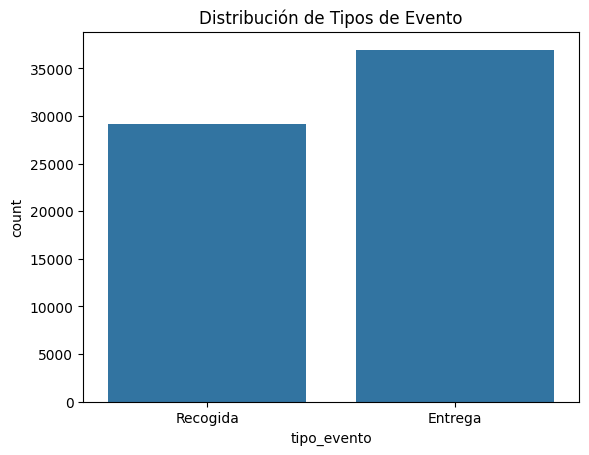

In [173]:
sns.countplot(data=df_union, x='tipo_evento')
plt.title('Distribución de Tipos de Evento')
plt.show()

Este data set nos muestra el evento de entrega o recogida de una mercancía con el tiempo exacto en el que ocurrió, y el clima que había en ese momento.

In [174]:
f.explorar_df(df_union)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66146 entries, 0 to 66145
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_evento              66146 non-null  object        
 1   id_carga               66146 non-null  object        
 2   id_viaje               66146 non-null  object        
 3   tipo_evento            66146 non-null  object        
 4   fecha_hora_programada  66146 non-null  object        
 5   fecha_hora_real        66146 non-null  datetime64[ns]
 6   minutos_de_detencion   66146 non-null  int64         
 7   indicador_tiempo_hora  66146 non-null  bool          
 8   ciudad                 66146 non-null  object        
 9   estado                 66146 non-null  object        
 10  fecha                  66146 non-null  datetime64[ns]
 11  hora                   66146 non-null  object        
 12  tem_max_C              66146 non-null  float64       
 13  t

In [175]:
df_union.to_csv('df_union_estudio.csv', index=False)

# Veamos el data set de rutas

In [176]:
df_rutas=pd.read_csv("data/rutas.csv")

In [177]:
df_rutas.head()

,route_id,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days
0,RTE00001,Atlanta,GA,Chicago,IL,677,1.70,0.19,1
1,RTE00002,Atlanta,GA,Miami,FL,697,2.08,0.22,1
2,RTE00003,Chicago,IL,Los Angeles,CA,2003,2.55,0.29,3
3,RTE00004,Chicago,IL,Portland,OR,2017,1.84,0.19,3
4,RTE00005,Chicago,IL,Las Vegas,NV,1749,2.41,0.26,3


In [178]:
df_rutas.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   route_id                58 non-null     object 
 1   origin_city             58 non-null     object 
 2   origin_state            58 non-null     object 
 3   destination_city        58 non-null     object 
 4   destination_state       58 non-null     object 
 5   typical_distance_miles  58 non-null     int64  
 6   base_rate_per_mile      58 non-null     float64
 7   fuel_surcharge_rate     58 non-null     float64
 8   typical_transit_days    58 non-null     int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 4.2+ KB


In [179]:
cam={"route_id":"id_ruta","origin_city": "ciudad_origen","origin_state": "estado_origen", "destination_city": "ciudad_destino","destination_state" : "estado_destino","typical_distance_miles":"distancia_tipica_millas", "base_rate_per_mile": "tarifa_base_por_milla","fuel_surcharge_rate":"tasa_de_recargo_combustible", "typical_transit_days":"dias_de_transito_tipicos"}

In [180]:
df_rutas=df_rutas.rename(columns=cam)

In [181]:
df_rutas.head()

,id_ruta,ciudad_origen,estado_origen,ciudad_destino,estado_destino,distancia_tipica_millas,tarifa_base_por_milla,tasa_de_recargo_combustible,dias_de_transito_tipicos
0,RTE00001,Atlanta,GA,Chicago,IL,677,1.70,0.19,1
1,RTE00002,Atlanta,GA,Miami,FL,697,2.08,0.22,1
2,RTE00003,Chicago,IL,Los Angeles,CA,2003,2.55,0.29,3
3,RTE00004,Chicago,IL,Portland,OR,2017,1.84,0.19,3
4,RTE00005,Chicago,IL,Las Vegas,NV,1749,2.41,0.26,3


In [182]:
df_rutas.columns

Index(['id_ruta', 'ciudad_origen', 'estado_origen', 'ciudad_destino',
       'estado_destino', 'distancia_tipica_millas', 'tarifa_base_por_milla',
       'tasa_de_recargo_combustible', 'dias_de_transito_tipicos'],
      dtype='object')

In [183]:
df_rutas= f.convertir_km(df_rutas,"distancia_tipica_millas")

In [184]:
df_rutas.head()

,id_ruta,ciudad_origen,estado_origen,ciudad_destino,estado_destino,distancia_tipica_millas,distancia_km,tarifa_base_por_milla,tasa_de_recargo_combustible,dias_de_transito_tipicos
0,RTE00001,Atlanta,GA,Chicago,IL,677,1089.53,1.70,0.19,1
1,RTE00002,Atlanta,GA,Miami,FL,697,1121.71,2.08,0.22,1
2,RTE00003,Chicago,IL,Los Angeles,CA,2003,3223.52,2.55,0.29,3
3,RTE00004,Chicago,IL,Portland,OR,2017,3246.05,1.84,0.19,3
4,RTE00005,Chicago,IL,Las Vegas,NV,1749,2814.74,2.41,0.26,3


In [185]:
df_rutas=f.convertir_a_eur(df_rutas,"tarifa_base_por_milla")

In [186]:
df_rutas.head()

,id_ruta,ciudad_origen,estado_origen,ciudad_destino,estado_destino,distancia_tipica_millas,distancia_km,tarifa_base_por_milla,ingreso_eur,tasa_de_recargo_combustible,dias_de_transito_tipicos
0,RTE00001,Atlanta,GA,Chicago,IL,677,1089.53,1.70,1.45,0.19,1
1,RTE00002,Atlanta,GA,Miami,FL,697,1121.71,2.08,1.77,0.22,1
2,RTE00003,Chicago,IL,Los Angeles,CA,2003,3223.52,2.55,2.17,0.29,3
3,RTE00004,Chicago,IL,Portland,OR,2017,3246.05,1.84,1.57,0.19,3
4,RTE00005,Chicago,IL,Las Vegas,NV,1749,2814.74,2.41,2.05,0.26,3


In [187]:
df_rutas = df_rutas.rename(columns={"ingreso_eur": "tarifa_base_milla_eur"})

In [188]:
df_rutas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_ruta                      58 non-null     object 
 1   ciudad_origen                58 non-null     object 
 2   estado_origen                58 non-null     object 
 3   ciudad_destino               58 non-null     object 
 4   estado_destino               58 non-null     object 
 5   distancia_tipica_millas      58 non-null     int64  
 6   distancia_km                 58 non-null     float64
 7   tarifa_base_por_milla        58 non-null     float64
 8   tarifa_base_milla_eur        58 non-null     float64
 9   tasa_de_recargo_combustible  58 non-null     float64
 10  dias_de_transito_tipicos     58 non-null     int64  
dtypes: float64(4), int64(2), object(5)
memory usage: 5.1+ KB


In [189]:
df_rutas.columns

Index(['id_ruta', 'ciudad_origen', 'estado_origen', 'ciudad_destino',
       'estado_destino', 'distancia_tipica_millas', 'distancia_km',
       'tarifa_base_por_milla', 'tarifa_base_milla_eur',
       'tasa_de_recargo_combustible', 'dias_de_transito_tipicos'],
      dtype='object')

Analizando esto vemos que tenemos 58 diferentes rutas de estudio

Creamos el csv de estudio para el análisis

In [190]:
df_rutas.to_csv('df_rutas_estudio.csv', index=False)

# Veamos ahora el data frame de los clientes

In [191]:
df_clientes=pd.read_csv("data/clientes.csv")

In [192]:
df_clientes.head()

,customer_id,customer_name,customer_type,credit_terms_days,primary_freight_type,account_status,contract_start_date,annual_revenue_potential
0,CUST00001,Metro Wholesale,Dedicated,60,General,Inactive,2020-02-20,985117
1,CUST00002,National Retail,Contract,30,Retail,Active,2021-06-02,4936566
2,CUST00003,XYZ Industries,Contract,30,Consumer Goods,Active,2020-09-04,3102814
3,CUST00004,American Corp,Contract,15,Food/Beverage,Active,2020-11-29,3948027
4,CUST00005,American Distribution,Spot,45,Consumer Goods,Active,2020-02-04,3682564


In [193]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               200 non-null    object
 1   customer_name             200 non-null    object
 2   customer_type             200 non-null    object
 3   credit_terms_days         200 non-null    int64 
 4   primary_freight_type      200 non-null    object
 5   account_status            200 non-null    object
 6   contract_start_date       200 non-null    object
 7   annual_revenue_potential  200 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 12.6+ KB


In [194]:
df_clientes.columns

Index(['customer_id', 'customer_name', 'customer_type', 'credit_terms_days',
       'primary_freight_type', 'account_status', 'contract_start_date',
       'annual_revenue_potential'],
      dtype='object')

In [195]:
f.categorico(df_clientes,"customer_name")

customer_name
First Group                 7
First Logistics             5
XYZ Wholesale               4
Continental Supply Chain    4
Metro Wholesale             4
                           ..
Pacific Foods               1
Elite Distribution          1
Pacific Group               1
Premier Supply Chain        1
Elite Wholesale             1
Name: count, Length: 107, dtype: int64
['Metro Wholesale' 'National Retail' 'XYZ Industries' 'American Corp'
 'American Distribution' 'American Industries' 'Superior Distribution'
 'American Logistics' 'XYZ Wholesale' 'National Logistics' 'First Group'
 'ABC Distribution' 'Pacific Corp' 'Elite Foods' 'United Industries'
 'Superior Supply Chain' 'ABC Retail' 'American Supply Chain' 'First Corp'
 'Elite Industries' 'Continental Supply Chain' 'Continental Industries'
 'XYZ Distribution' 'Pacific Retail' 'ABC Supply Chain' 'Superior Foods'
 'ABC Manufacturing' 'American Manufacturing' 'Continental Wholesale'
 'XYZ Foods' 'Elite Retail' 'United Distribu

In [196]:
f.categorico(df_clientes,"primary_freight_type")

primary_freight_type
Automotive        41
Food/Beverage     37
Retail            35
Electronics       33
Consumer Goods    30
General           24
Name: count, dtype: int64
['General' 'Retail' 'Consumer Goods' 'Food/Beverage' 'Automotive'
 'Electronics']
6


Cambiaremos las columnas con sus nombres al español

In [197]:
nombre={'customer_id': "id_cliente", 'customer_name': "nombre_cliente", 'customer_type': "tipo_cliente", 'credit_terms_days': "dias_plazo_credito",
        'primary_freight_type': "tipo_carga_principal", 'account_status': "estado_cuenta", 'contract_start_date': "fecha_inicio_contrato",
        'annual_revenue_potential': "potencial_ingresos_anuales"}


In [198]:
df_clientes.rename(columns=nombre, inplace=True)

In [199]:
df_clientes.head()

,id_cliente,nombre_cliente,tipo_cliente,dias_plazo_credito,tipo_carga_principal,estado_cuenta,fecha_inicio_contrato,potencial_ingresos_anuales
0,CUST00001,Metro Wholesale,Dedicated,60,General,Inactive,2020-02-20,985117
1,CUST00002,National Retail,Contract,30,Retail,Active,2021-06-02,4936566
2,CUST00003,XYZ Industries,Contract,30,Consumer Goods,Active,2020-09-04,3102814
3,CUST00004,American Corp,Contract,15,Food/Beverage,Active,2020-11-29,3948027
4,CUST00005,American Distribution,Spot,45,Consumer Goods,Active,2020-02-04,3682564


In [200]:
f.categorico(df_clientes,"tipo_cliente")

tipo_cliente
Contract     75
Spot         63
Dedicated    62
Name: count, dtype: int64
['Dedicated' 'Contract' 'Spot']
3


In [201]:
df_clientes=f.cambiar_filas(df_clientes, 'tipo_cliente', 'Contract', 'Contrato')
df_clientes=f.cambiar_filas(df_clientes, 'tipo_cliente', 'Spot', 'Puntual')
df_clientes=f.cambiar_filas(df_clientes, 'tipo_cliente', 'Dedicated', 'Dedicado')


In [202]:
df_clientes=f.cambiar_filas(df_clientes, 'tipo_carga_principal', 'Retail', 'Venta por menor')
df_clientes=f.cambiar_filas(df_clientes, 'tipo_carga_principal', 'Consumer Goods', 'Bienes de consumo')
df_clientes=f.cambiar_filas(df_clientes, 'tipo_carga_principal', 'Food/Beverage', 'Alimentos/Bebidas')
df_clientes=f.cambiar_filas(df_clientes, 'tipo_carga_principal', 'Automotive', 'Automotriz')
df_clientes=f.cambiar_filas(df_clientes, 'tipo_carga_principal', 'Electronics', 'Electrónica')


In [203]:
df_clientes.head()

,id_cliente,nombre_cliente,tipo_cliente,dias_plazo_credito,tipo_carga_principal,estado_cuenta,fecha_inicio_contrato,potencial_ingresos_anuales
0,CUST00001,Metro Wholesale,Dedicado,60,General,Inactive,2020-02-20,985117
1,CUST00002,National Retail,Contrato,30,Venta por menor,Active,2021-06-02,4936566
2,CUST00003,XYZ Industries,Contrato,30,Bienes de consumo,Active,2020-09-04,3102814
3,CUST00004,American Corp,Contrato,15,Alimentos/Bebidas,Active,2020-11-29,3948027
4,CUST00005,American Distribution,Puntual,45,Bienes de consumo,Active,2020-02-04,3682564


In [204]:
df_clientes=f.convertir_a_eur(df_clientes,"potencial_ingresos_anuales")


In [205]:
df_clientes.columns

Index(['id_cliente', 'nombre_cliente', 'tipo_cliente', 'dias_plazo_credito',
       'tipo_carga_principal', 'estado_cuenta', 'fecha_inicio_contrato',
       'potencial_ingresos_anuales', 'ingreso_eur'],
      dtype='object')

Tenemos 107 clientes con información detallada clasificados en 3 tipos de clientes diferentes: Contrato, Puntual y Dedicado. Además, tenemos información sobre el tipo de carga principal que transporta cada cliente.

In [206]:
df_clientes.to_csv('df_clientes_estudio.csv', index=False)

# Veamos el data set de los viajes

In [207]:
df_viajes=pd.read_csv("data/viajes.csv")

In [208]:
df_viajes.info( )

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_id                85410 non-null  object 
 1   load_id                85410 non-null  object 
 2   driver_id              83696 non-null  object 
 3   truck_id               83738 non-null  object 
 4   trailer_id             83730 non-null  object 
 5   dispatch_date          85410 non-null  object 
 6   actual_distance_miles  85410 non-null  int64  
 7   actual_duration_hours  85410 non-null  float64
 8   fuel_gallons_used      85410 non-null  float64
 9   average_mpg            85410 non-null  float64
 10  idle_time_hours        85410 non-null  float64
 11  trip_status            85410 non-null  object 
dtypes: float64(4), int64(1), object(7)
memory usage: 7.8+ MB


In [209]:
df_viajes.head()

,trip_id,load_id,driver_id,truck_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status
0,TRIP00000001,LOAD00000001,DRV00117,TRK00035,TRL00167,2022-01-01,1314,26.2,183.8,7.15,3.5,Completed
1,TRIP00000002,LOAD00000002,DRV00141,TRK00108,TRL00082,2022-01-01,515,8.6,93.6,5.50,8.3,Completed
2,TRIP00000003,LOAD00000003,DRV00032,TRK00031,TRL00138,2022-01-01,2509,45.0,339.1,7.40,12.0,Completed
3,TRIP00000004,LOAD00000004,DRV00083,TRK00105,TRL00018,2022-01-01,717,11.1,110.3,6.50,9.6,Completed
4,TRIP00000005,LOAD00000005,DRV00044,TRK00076,TRL00054,2022-01-01,2243,35.0,328.9,6.82,11.6,Completed


In [210]:
df_viajes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_id                85410 non-null  object 
 1   load_id                85410 non-null  object 
 2   driver_id              83696 non-null  object 
 3   truck_id               83738 non-null  object 
 4   trailer_id             83730 non-null  object 
 5   dispatch_date          85410 non-null  object 
 6   actual_distance_miles  85410 non-null  int64  
 7   actual_duration_hours  85410 non-null  float64
 8   fuel_gallons_used      85410 non-null  float64
 9   average_mpg            85410 non-null  float64
 10  idle_time_hours        85410 non-null  float64
 11  trip_status            85410 non-null  object 
dtypes: float64(4), int64(1), object(7)
memory usage: 7.8+ MB


In [211]:
df_viajes.columns

Index(['trip_id', 'load_id', 'driver_id', 'truck_id', 'trailer_id',
       'dispatch_date', 'actual_distance_miles', 'actual_duration_hours',
       'fuel_gallons_used', 'average_mpg', 'idle_time_hours', 'trip_status'],
      dtype='object')

In [212]:
col={'trip_id': 'id_viaje', 'load_id': 'id_carga', 'driver_id': 'id_conductor', 'truck_id': 'id_camion', 'trailer_id': 'id_remolque',
        'dispatch_date': 'fecha_despacho', 'actual_distance_miles': 'distancia_real_millas', 'actual_duration_hours': 'duracion_real_horas',   
        'fuel_gallons_used': 'galones_combustible_usados', 'average_mpg': 'mpg_promedio', 'idle_time_hours': 'horas_de_ralenti(RPM)', 'trip_status': 'estado_viaje'}

In [213]:
df_viajes.rename(columns=col, inplace=True)

In [214]:
df_viajes.head()

,id_viaje,id_carga,id_conductor,id_camion,id_remolque,fecha_despacho,distancia_real_millas,duracion_real_horas,galones_combustible_usados,mpg_promedio,horas_de_ralenti(RPM),estado_viaje
0,TRIP00000001,LOAD00000001,DRV00117,TRK00035,TRL00167,2022-01-01,1314,26.2,183.8,7.15,3.5,Completed
1,TRIP00000002,LOAD00000002,DRV00141,TRK00108,TRL00082,2022-01-01,515,8.6,93.6,5.50,8.3,Completed
2,TRIP00000003,LOAD00000003,DRV00032,TRK00031,TRL00138,2022-01-01,2509,45.0,339.1,7.40,12.0,Completed
3,TRIP00000004,LOAD00000004,DRV00083,TRK00105,TRL00018,2022-01-01,717,11.1,110.3,6.50,9.6,Completed
4,TRIP00000005,LOAD00000005,DRV00044,TRK00076,TRL00054,2022-01-01,2243,35.0,328.9,6.82,11.6,Completed


In [215]:
f.categorico(df_viajes, 'estado_viaje')

estado_viaje
Completed    85410
Name: count, dtype: int64
['Completed']
1


In [216]:
df_viajes.columns

Index(['id_viaje', 'id_carga', 'id_conductor', 'id_camion', 'id_remolque',
       'fecha_despacho', 'distancia_real_millas', 'duracion_real_horas',
       'galones_combustible_usados', 'mpg_promedio', 'horas_de_ralenti(RPM)',
       'estado_viaje'],
      dtype='object')

In [217]:
df_viajes=df_viajes.drop(['id_conductor','id_camion','id_remolque'], axis=1)

In [218]:
df_viajes.head()

,id_viaje,id_carga,fecha_despacho,distancia_real_millas,duracion_real_horas,galones_combustible_usados,mpg_promedio,horas_de_ralenti(RPM),estado_viaje
0,TRIP00000001,LOAD00000001,2022-01-01,1314,26.2,183.8,7.15,3.5,Completed
1,TRIP00000002,LOAD00000002,2022-01-01,515,8.6,93.6,5.50,8.3,Completed
2,TRIP00000003,LOAD00000003,2022-01-01,2509,45.0,339.1,7.40,12.0,Completed
3,TRIP00000004,LOAD00000004,2022-01-01,717,11.1,110.3,6.50,9.6,Completed
4,TRIP00000005,LOAD00000005,2022-01-01,2243,35.0,328.9,6.82,11.6,Completed


In [219]:
df_viajes=f.convertir_km(df_viajes, 'distancia_real_millas')

In [220]:
df_viajes.columns

Index(['id_viaje', 'id_carga', 'fecha_despacho', 'distancia_real_millas',
       'distancia_km', 'duracion_real_horas', 'galones_combustible_usados',
       'mpg_promedio', 'horas_de_ralenti(RPM)', 'estado_viaje'],
      dtype='object')

In [221]:
df_viajes.to_csv('df_viajes_estudio.csv', index=False)

# Veamos el data set de Carga

In [222]:
df_carga=pd.read_csv('data/cargas.csv')

In [223]:
df_carga.head()

,load_id,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,load_status,booking_type
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,3045.23,406.72,100,Completed,Spot
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,1224.48,98.61,0,Completed,Dedicated
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,7171.12,792.88,0,Completed,Spot
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerated,33274,10,1308.20,141.33,50,Completed,Spot
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Dry Van,40257,10,3317.18,738.48,0,Completed,Spot


In [224]:
df_carga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   load_id              85410 non-null  object 
 1   customer_id          85410 non-null  object 
 2   route_id             85410 non-null  object 
 3   load_date            85410 non-null  object 
 4   load_type            85410 non-null  object 
 5   weight_lbs           85410 non-null  int64  
 6   pieces               85410 non-null  int64  
 7   revenue              85410 non-null  float64
 8   fuel_surcharge       85410 non-null  float64
 9   accessorial_charges  85410 non-null  int64  
 10  load_status          85410 non-null  object 
 11  booking_type         85410 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 7.8+ MB


In [225]:
df_carga.columns

Index(['load_id', 'customer_id', 'route_id', 'load_date', 'load_type',
       'weight_lbs', 'pieces', 'revenue', 'fuel_surcharge',
       'accessorial_charges', 'load_status', 'booking_type'],
      dtype='object')

In [226]:
lista={'load_id':'id_carga','customer_id':'id_cliente','route_id':'id_ruta','load_date':'fecha_carga','load_type':'tipo_carga',
        'weight_lbs':'peso_lbs','pieces':'piezas','revenue':'ingreso_dolar','fuel_surcharge':'recargo_combustible','accessorial_charges':'cargos_accesorios',
        'load_status':'estado_carga','booking_type':'tipo_reserva'}

In [227]:
df_carga.rename(columns=lista, inplace=True)

In [228]:
df_carga.head()

,id_carga,id_cliente,id_ruta,fecha_carga,tipo_carga,peso_lbs,piezas,ingreso_dolar,recargo_combustible,cargos_accesorios,estado_carga,tipo_reserva
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,3045.23,406.72,100,Completed,Spot
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,1224.48,98.61,0,Completed,Dedicated
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,7171.12,792.88,0,Completed,Spot
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerated,33274,10,1308.20,141.33,50,Completed,Spot
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Dry Van,40257,10,3317.18,738.48,0,Completed,Spot


In [229]:
f.categorico(df_carga,'tipo_carga')


tipo_carga
Refrigerated    42946
Dry Van         42464
Name: count, dtype: int64
['Dry Van' 'Refrigerated']
2


In [230]:
f.categorico(df_carga,'estado_carga')

estado_carga
Completed    85410
Name: count, dtype: int64
['Completed']
1


In [231]:
f.categorico(df_carga,'tipo_reserva')

tipo_reserva
Dedicated    42337
Contract     21545
Spot         21528
Name: count, dtype: int64
['Spot' 'Dedicated' 'Contract']
3


In [232]:
df_carga=f.cambiar_filas(df_carga, 'tipo_reserva', 'Contract', 'Contrato')
df_carga=f.cambiar_filas(df_carga, 'tipo_reserva', 'Spot', 'Puntual')
df_carga=f.cambiar_filas(df_carga, 'tipo_reserva', 'Dedicated', 'Dedicado')

In [233]:
df_carga=f.cambiar_filas(df_carga, 'tipo_carga', 'Refrigerated', 'Refrigerado')
df_carga=f.cambiar_filas(df_carga, 'tipo_carga', 'Dry Van', 'Seco')


In [234]:
df_carga.head()

,id_carga,id_cliente,id_ruta,fecha_carga,tipo_carga,peso_lbs,piezas,ingreso_dolar,recargo_combustible,cargos_accesorios,estado_carga,tipo_reserva
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Seco,19178,13,3045.23,406.72,100,Completed,Puntual
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Seco,27761,22,1224.48,98.61,0,Completed,Dedicado
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerado,35594,16,7171.12,792.88,0,Completed,Puntual
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerado,33274,10,1308.20,141.33,50,Completed,Puntual
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Seco,40257,10,3317.18,738.48,0,Completed,Puntual


In [235]:
df_carga=f.convertir_kg(df_carga,"peso_lbs")

In [236]:
df_carga=f.convertir_a_eur(df_carga, 'ingreso_dolar')

In [237]:
df_carga.columns

Index(['id_carga', 'id_cliente', 'id_ruta', 'fecha_carga', 'tipo_carga',
       'peso_lbs', 'peso_kg', 'piezas', 'ingreso_dolar', 'ingreso_eur',
       'recargo_combustible', 'cargos_accesorios', 'estado_carga',
       'tipo_reserva'],
      dtype='object')

In [238]:
df_carga.to_csv('df_carga_estudio.csv', index=False)

# Veamos el data set de compras de combustible

In [239]:
df_combustible=pd.read_csv("data/compras_combustible.csv")

In [240]:
df_combustible.head()

,fuel_purchase_id,trip_id,truck_id,driver_id,purchase_date,location_city,location_state,gallons,price_per_gallon,total_cost,fuel_card_number
0,FUEL00000001,TRIP00051284,TRK00045,DRV00102,2023-10-22 05:00:00,Columbus,MN,131.6,3.399,447.31,FC567161
1,FUEL00000002,TRIP00073723,TRK00013,NaN,2024-08-04 08:00:00,New York,AZ,139.9,3.180,444.88,FC717910
2,FUEL00000003,TRIP00018286,TRK00024,DRV00142,2022-08-23 13:00:00,Seattle,NE,189.3,3.804,720.10,FC912816
3,FUEL00000004,TRIP00008465,TRK00018,DRV00047,2022-04-20 00:00:00,Memphis,NY,130.7,3.579,467.78,FC776357
4,FUEL00000005,TRIP00069700,TRK00054,NaN,2024-06-13 09:00:00,Columbus,AZ,185.3,3.422,634.10,FC391024


In [241]:
df_combustible.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196442 entries, 0 to 196441
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   fuel_purchase_id  196442 non-null  object 
 1   trip_id           196442 non-null  object 
 2   truck_id          192562 non-null  object 
 3   driver_id         192454 non-null  object 
 4   purchase_date     196442 non-null  object 
 5   location_city     196442 non-null  object 
 6   location_state    196442 non-null  object 
 7   gallons           196442 non-null  float64
 8   price_per_gallon  196442 non-null  float64
 9   total_cost        196442 non-null  float64
 10  fuel_card_number  196442 non-null  object 
dtypes: float64(3), object(8)
memory usage: 16.5+ MB


In [242]:
df_combustible.columns

Index(['fuel_purchase_id', 'trip_id', 'truck_id', 'driver_id', 'purchase_date',
       'location_city', 'location_state', 'gallons', 'price_per_gallon',
       'total_cost', 'fuel_card_number'],
      dtype='object')

In [243]:
cam= {'fuel_purchase_id':'id_compra_combustible', 'trip_id':'id_viaje', 'truck_id':'id_camion', 'driver_id':'id_conductor', 'purchase_date':'fecha_compra',
'location_city':'ciudad', 'location_state':'estado', 'gallons':'galones', 'price_per_gallon':'precio_por_galon',
'total_cost':'costo_total', 'fuel_card_number':'numero_tarjeta_combustible'}

In [244]:
df_combustible.rename(columns=cam, inplace=True)

In [245]:
df_combustible.head()

,id_compra_combustible,id_viaje,id_camion,id_conductor,fecha_compra,ciudad,estado,galones,precio_por_galon,costo_total,numero_tarjeta_combustible
0,FUEL00000001,TRIP00051284,TRK00045,DRV00102,2023-10-22 05:00:00,Columbus,MN,131.6,3.399,447.31,FC567161
1,FUEL00000002,TRIP00073723,TRK00013,NaN,2024-08-04 08:00:00,New York,AZ,139.9,3.180,444.88,FC717910
2,FUEL00000003,TRIP00018286,TRK00024,DRV00142,2022-08-23 13:00:00,Seattle,NE,189.3,3.804,720.10,FC912816
3,FUEL00000004,TRIP00008465,TRK00018,DRV00047,2022-04-20 00:00:00,Memphis,NY,130.7,3.579,467.78,FC776357
4,FUEL00000005,TRIP00069700,TRK00054,NaN,2024-06-13 09:00:00,Columbus,AZ,185.3,3.422,634.10,FC391024


In [246]:
df_combustible=df_combustible.drop(columns=['id_camion','id_conductor',"numero_tarjeta_combustible"])

In [247]:
df_combustible=f.convertir_a_eur(df_combustible, 'costo_total')

In [248]:
df_combustible.columns

Index(['id_compra_combustible', 'id_viaje', 'fecha_compra', 'ciudad', 'estado',
       'galones', 'precio_por_galon', 'costo_total', 'ingreso_eur'],
      dtype='object')

In [249]:
df_combustible.rename(columns={'costo_total': 'costo_total_usd',"ingreso_eur": "costo_total_eur"}, inplace=True)

In [250]:
df_combustible.head()


,id_compra_combustible,id_viaje,fecha_compra,ciudad,estado,galones,precio_por_galon,costo_total_usd,costo_total_eur
0,FUEL00000001,TRIP00051284,2023-10-22 05:00:00,Columbus,MN,131.6,3.399,447.31,380.59
1,FUEL00000002,TRIP00073723,2024-08-04 08:00:00,New York,AZ,139.9,3.180,444.88,378.52
2,FUEL00000003,TRIP00018286,2022-08-23 13:00:00,Seattle,NE,189.3,3.804,720.10,612.69
3,FUEL00000004,TRIP00008465,2022-04-20 00:00:00,Memphis,NY,130.7,3.579,467.78,398.01
4,FUEL00000005,TRIP00069700,2024-06-13 09:00:00,Columbus,AZ,185.3,3.422,634.10,539.52


In [251]:
df_combustible.columns

Index(['id_compra_combustible', 'id_viaje', 'fecha_compra', 'ciudad', 'estado',
       'galones', 'precio_por_galon', 'costo_total_usd', 'costo_total_eur'],
      dtype='object')

In [252]:
df_combustible.to_csv('df_combustible_estudio.csv', index=False)

# Cargamos el dataframe incidente seguridad

In [253]:
df_incidente=pd.read_csv("data/incidentes_seguridad.csv")

In [254]:
df_incidente.head()


,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.00,12629.26,True,Severe incident involving equipment
1,INC00000002,TRIP00032462,TRK00084,DRV00006,2023-02-19 11:00:00,Moving Violation,Columbus,NC,False,False,2700.70,14284.24,16984.94,False,Severe incident involving weather
2,INC00000003,TRIP00067583,TRK00106,DRV00119,2024-05-20 01:00:00,Customer Complaint,Seattle,OK,True,False,24302.32,0.00,24302.32,True,Minor incident involving traffic
3,INC00000004,TRIP00049128,TRK00085,DRV00134,2023-09-26 03:00:00,Equipment Damage,Kansas City,TN,True,False,4879.13,0.00,4879.13,True,Moderate incident involving equipment
4,INC00000005,TRIP00062884,TRK00014,DRV00133,2024-03-20 14:00:00,DOT Violation,Las Vegas,IN,False,False,14951.40,0.00,14951.40,False,Minor incident involving other driver


In [255]:
df_incidente.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   incident_id          170 non-null    object 
 1   trip_id              170 non-null    object 
 2   truck_id             169 non-null    object 
 3   driver_id            169 non-null    object 
 4   incident_date        170 non-null    object 
 5   incident_type        170 non-null    object 
 6   location_city        170 non-null    object 
 7   location_state       170 non-null    object 
 8   at_fault_flag        170 non-null    bool   
 9   injury_flag          170 non-null    bool   
 10  vehicle_damage_cost  170 non-null    float64
 11  cargo_damage_cost    170 non-null    float64
 12  claim_amount         170 non-null    float64
 13  preventable_flag     170 non-null    bool   
 14  description          170 non-null    object 
dtypes: bool(3), float64(3), object(9)
memory

In [256]:
df_incidente.columns

Index(['incident_id', 'trip_id', 'truck_id', 'driver_id', 'incident_date',
       'incident_type', 'location_city', 'location_state', 'at_fault_flag',
       'injury_flag', 'vehicle_damage_cost', 'cargo_damage_cost',
       'claim_amount', 'preventable_flag', 'description'],
      dtype='object')

In [257]:
loc= {'incident_id':'id_incidente', 'trip_id':'id_viaje', 'truck_id':'id_camion', 'driver_id':'id_conductor', 'incident_date':'fecha_incidente',
'incident_type':'tipo_incidente', 'location_city':'ciudad', 'location_state':'estado', 'at_fault_flag':'indicador_de_falla',
'injury_flag':'indicador_de_lesion', 'vehicle_damage_cost':'costo_vehiculo', 'cargo_damage_cost':'costo_carga',
'claim_amount':'monto_reclamacion', 'preventable_flag':'indicador_prevenible', 'description':'descripcion'}

In [258]:
df_incidente = df_incidente.rename(columns=loc)

In [259]:
df_incidente.head()

,id_incidente,id_viaje,id_camion,id_conductor,fecha_incidente,tipo_incidente,ciudad,estado,indicador_de_falla,indicador_de_lesion,costo_vehiculo,costo_carga,monto_reclamacion,indicador_prevenible,descripcion
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.00,12629.26,True,Severe incident involving equipment
1,INC00000002,TRIP00032462,TRK00084,DRV00006,2023-02-19 11:00:00,Moving Violation,Columbus,NC,False,False,2700.70,14284.24,16984.94,False,Severe incident involving weather
2,INC00000003,TRIP00067583,TRK00106,DRV00119,2024-05-20 01:00:00,Customer Complaint,Seattle,OK,True,False,24302.32,0.00,24302.32,True,Minor incident involving traffic
3,INC00000004,TRIP00049128,TRK00085,DRV00134,2023-09-26 03:00:00,Equipment Damage,Kansas City,TN,True,False,4879.13,0.00,4879.13,True,Moderate incident involving equipment
4,INC00000005,TRIP00062884,TRK00014,DRV00133,2024-03-20 14:00:00,DOT Violation,Las Vegas,IN,False,False,14951.40,0.00,14951.40,False,Minor incident involving other driver


In [260]:
df_incidente=df_incidente.drop(columns=['id_camion','id_conductor'])

In [261]:
df_incidente.columns

Index(['id_incidente', 'id_viaje', 'fecha_incidente', 'tipo_incidente',
       'ciudad', 'estado', 'indicador_de_falla', 'indicador_de_lesion',
       'costo_vehiculo', 'costo_carga', 'monto_reclamacion',
       'indicador_prevenible', 'descripcion'],
      dtype='object')

In [262]:
f.categorico(df_incidente, 'tipo_incidente')

tipo_incidente
DOT Violation         39
Accident              35
Equipment Damage      35
Customer Complaint    34
Moving Violation      27
Name: count, dtype: int64
['Moving Violation' 'Customer Complaint' 'Equipment Damage'
 'DOT Violation' 'Accident']
5


In [263]:
df_incidente=f.cambiar_filas(df_incidente, 'tipo_incidente', 'Moving Violation', 'Infracción de tránsito')
df_incidente=f.cambiar_filas(df_incidente, 'tipo_incidente', 'Customer Complaint', 'Queja del cliente')
df_incidente=f.cambiar_filas(df_incidente, 'tipo_incidente', 'Equipment Damage', 'Daño de equipo')
df_incidente=f.cambiar_filas(df_incidente, 'tipo_incidente', 'DOT Violation', 'Fallo mecánico o exceso horas permitidas')
df_incidente=f.cambiar_filas(df_incidente, 'tipo_incidente', 'Accident', 'Accidente')



In [264]:
df_incidente.head()

,id_incidente,id_viaje,fecha_incidente,tipo_incidente,ciudad,estado,indicador_de_falla,indicador_de_lesion,costo_vehiculo,costo_carga,monto_reclamacion,indicador_prevenible,descripcion
0,INC00000001,TRIP00036079,2023-04-09 14:00:00,Infracción de tránsito,Columbus,PA,True,False,12629.26,0.00,12629.26,True,Severe incident involving equipment
1,INC00000002,TRIP00032462,2023-02-19 11:00:00,Infracción de tránsito,Columbus,NC,False,False,2700.70,14284.24,16984.94,False,Severe incident involving weather
2,INC00000003,TRIP00067583,2024-05-20 01:00:00,Queja del cliente,Seattle,OK,True,False,24302.32,0.00,24302.32,True,Minor incident involving traffic
3,INC00000004,TRIP00049128,2023-09-26 03:00:00,Daño de equipo,Kansas City,TN,True,False,4879.13,0.00,4879.13,True,Moderate incident involving equipment
4,INC00000005,TRIP00062884,2024-03-20 14:00:00,Fallo mecánico o exceso horas permitidas,Las Vegas,IN,False,False,14951.40,0.00,14951.40,False,Minor incident involving other driver


In [265]:
f.categorico(df_incidente, 'descripcion')

descripcion
Severe incident involving weather           18
Moderate incident involving weather         18
Moderate incident involving traffic         18
Minor incident involving other driver       17
Moderate incident involving equipment       16
Minor incident involving equipment          15
Severe incident involving other driver      13
Severe incident involving equipment         12
Severe incident involving traffic           12
Minor incident involving traffic            11
Minor incident involving weather            10
Moderate incident involving other driver    10
Name: count, dtype: int64
['Severe incident involving equipment' 'Severe incident involving weather'
 'Minor incident involving traffic'
 'Moderate incident involving equipment'
 'Minor incident involving other driver'
 'Minor incident involving weather' 'Moderate incident involving traffic'
 'Moderate incident involving weather' 'Severe incident involving traffic'
 'Minor incident involving equipment'
 'Severe incident 

In [266]:
df_incidente = f.procesar_incidentes(df_incidente, 'descripcion')

In [267]:
df_incidente.head()

,id_incidente,id_viaje,fecha_incidente,tipo_incidente,ciudad,estado,indicador_de_falla,indicador_de_lesion,costo_vehiculo,costo_carga,monto_reclamacion,indicador_prevenible,descripcion,nivel,causa
0,INC00000001,TRIP00036079,2023-04-09 14:00:00,Infracción de tránsito,Columbus,PA,True,False,12629.26,0.00,12629.26,True,Severe incident involving equipment,Severe,equipment
1,INC00000002,TRIP00032462,2023-02-19 11:00:00,Infracción de tránsito,Columbus,NC,False,False,2700.70,14284.24,16984.94,False,Severe incident involving weather,Severe,weather
2,INC00000003,TRIP00067583,2024-05-20 01:00:00,Queja del cliente,Seattle,OK,True,False,24302.32,0.00,24302.32,True,Minor incident involving traffic,Minor,traffic
3,INC00000004,TRIP00049128,2023-09-26 03:00:00,Daño de equipo,Kansas City,TN,True,False,4879.13,0.00,4879.13,True,Moderate incident involving equipment,Moderate,equipment
4,INC00000005,TRIP00062884,2024-03-20 14:00:00,Fallo mecánico o exceso horas permitidas,Las Vegas,IN,False,False,14951.40,0.00,14951.40,False,Minor incident involving other driver,Minor,other driver


In [268]:
df_incidente = df_incidente.drop(columns=['descripcion'])

In [269]:
df_incidente.head()

,id_incidente,id_viaje,fecha_incidente,tipo_incidente,ciudad,estado,indicador_de_falla,indicador_de_lesion,costo_vehiculo,costo_carga,monto_reclamacion,indicador_prevenible,nivel,causa
0,INC00000001,TRIP00036079,2023-04-09 14:00:00,Infracción de tránsito,Columbus,PA,True,False,12629.26,0.00,12629.26,True,Severe,equipment
1,INC00000002,TRIP00032462,2023-02-19 11:00:00,Infracción de tránsito,Columbus,NC,False,False,2700.70,14284.24,16984.94,False,Severe,weather
2,INC00000003,TRIP00067583,2024-05-20 01:00:00,Queja del cliente,Seattle,OK,True,False,24302.32,0.00,24302.32,True,Minor,traffic
3,INC00000004,TRIP00049128,2023-09-26 03:00:00,Daño de equipo,Kansas City,TN,True,False,4879.13,0.00,4879.13,True,Moderate,equipment
4,INC00000005,TRIP00062884,2024-03-20 14:00:00,Fallo mecánico o exceso horas permitidas,Las Vegas,IN,False,False,14951.40,0.00,14951.40,False,Minor,other driver


In [270]:
df_incidente=f.cambiar_filas(df_incidente, 'nivel',"Severe","Grave")
df_incidente=f.cambiar_filas(df_incidente, 'nivel',"Minor","Leve")
df_incidente=f.cambiar_filas(df_incidente, 'nivel',"Moderate","Moderado")


In [271]:
df_incidente=f.cambiar_filas(df_incidente, 'causa', 'equipment', 'Equipo')
df_incidente=f.cambiar_filas(df_incidente, 'causa', 'weather', 'Clima')
df_incidente=f.cambiar_filas(df_incidente, 'causa', 'traffic', 'Tráfico')
df_incidente=f.cambiar_filas(df_incidente, 'causa', 'other driver', 'Otro conductor')

In [272]:
df_incidente.head()

,id_incidente,id_viaje,fecha_incidente,tipo_incidente,ciudad,estado,indicador_de_falla,indicador_de_lesion,costo_vehiculo,costo_carga,monto_reclamacion,indicador_prevenible,nivel,causa
0,INC00000001,TRIP00036079,2023-04-09 14:00:00,Infracción de tránsito,Columbus,PA,True,False,12629.26,0.00,12629.26,True,Grave,Equipo
1,INC00000002,TRIP00032462,2023-02-19 11:00:00,Infracción de tránsito,Columbus,NC,False,False,2700.70,14284.24,16984.94,False,Grave,Clima
2,INC00000003,TRIP00067583,2024-05-20 01:00:00,Queja del cliente,Seattle,OK,True,False,24302.32,0.00,24302.32,True,Leve,Tráfico
3,INC00000004,TRIP00049128,2023-09-26 03:00:00,Daño de equipo,Kansas City,TN,True,False,4879.13,0.00,4879.13,True,Moderado,Equipo
4,INC00000005,TRIP00062884,2024-03-20 14:00:00,Fallo mecánico o exceso horas permitidas,Las Vegas,IN,False,False,14951.40,0.00,14951.40,False,Leve,Otro conductor


In [273]:
df_incidente=f.convertir_a_eur(df_incidente,"monto_reclamacion")

In [274]:
df_incidente=df_incidente.rename(columns={'monto_reclamacion': 'monto_reclamacion_dolar',"ingreso_eur": "monto_reclamacion_eur"})

In [275]:
df_incidente.columns

Index(['id_incidente', 'id_viaje', 'fecha_incidente', 'tipo_incidente',
       'ciudad', 'estado', 'indicador_de_falla', 'indicador_de_lesion',
       'costo_vehiculo', 'costo_carga', 'monto_reclamacion_dolar',
       'monto_reclamacion_eur', 'indicador_prevenible', 'nivel', 'causa'],
      dtype='object')

In [276]:
df_incidente.head()

,id_incidente,id_viaje,fecha_incidente,tipo_incidente,ciudad,estado,indicador_de_falla,indicador_de_lesion,costo_vehiculo,costo_carga,monto_reclamacion_dolar,monto_reclamacion_eur,indicador_prevenible,nivel,causa
0,INC00000001,TRIP00036079,2023-04-09 14:00:00,Infracción de tránsito,Columbus,PA,True,False,12629.26,0.00,12629.26,10745.56,True,Grave,Equipo
1,INC00000002,TRIP00032462,2023-02-19 11:00:00,Infracción de tránsito,Columbus,NC,False,False,2700.70,14284.24,16984.94,14451.58,False,Grave,Clima
2,INC00000003,TRIP00067583,2024-05-20 01:00:00,Queja del cliente,Seattle,OK,True,False,24302.32,0.00,24302.32,20677.55,True,Leve,Tráfico
3,INC00000004,TRIP00049128,2023-09-26 03:00:00,Daño de equipo,Kansas City,TN,True,False,4879.13,0.00,4879.13,4151.39,True,Moderado,Equipo
4,INC00000005,TRIP00062884,2024-03-20 14:00:00,Fallo mecánico o exceso horas permitidas,Las Vegas,IN,False,False,14951.40,0.00,14951.40,12721.35,False,Leve,Otro conductor


In [277]:
df_incidente.columns

Index(['id_incidente', 'id_viaje', 'fecha_incidente', 'tipo_incidente',
       'ciudad', 'estado', 'indicador_de_falla', 'indicador_de_lesion',
       'costo_vehiculo', 'costo_carga', 'monto_reclamacion_dolar',
       'monto_reclamacion_eur', 'indicador_prevenible', 'nivel', 'causa'],
      dtype='object')

In [278]:
df_incidente.to_csv("df_incidente_estudio.csv", index=False)